In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter

# DATA PREPARATION

In [3]:
# Load the dataset
df = pd.read_csv('telco.csv')

# Drop ID as it's not a predictor
df = df.drop(columns=['ID'])

# Convert target variable 'churn' to binary (1 = Yes, 0 = No)
df['churn'] = df['churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Survival analysis fails if duration (tenure) is exactly 0.
# We replace 0 with a very small number (e.g., 0.001)
df['tenure'] = df['tenure'].replace(0, 0.001)

# One-hot encode categorical variables
categorical_cols = ['region', 'marital', 'ed', 'retire', 'gender', 'voice', 'internet', 'forward', 'custcat']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# PARAMETRIC MODELS & COMPARISON

In [4]:
# Initialize the AFT fitters
weibull_aft = WeibullAFTFitter()
lognorm_aft = LogNormalAFTFitter()
loglogis_aft = LogLogisticAFTFitter()

# Fit the models
weibull_aft.fit(df_encoded, duration_col='tenure', event_col='churn')
lognorm_aft.fit(df_encoded, duration_col='tenure', event_col='churn')
loglogis_aft.fit(df_encoded, duration_col='tenure', event_col='churn')

# Compare AIC scores to select the best model (Lowest AIC is best)
print(f"Weibull AIC: {weibull_aft.AIC_:.2f}")
print(f"Log-Normal AIC: {lognorm_aft.AIC_:.2f}")
print(f"Log-Logistic AIC: {loglogis_aft.AIC_:.2f}")

# Find the best model programmatically
models = {'Weibull': weibull_aft, 'Log-Normal': lognorm_aft, 'Log-Logistic': loglogis_aft}
best_model_name = min(models, key=lambda k: models[k].AIC_)
best_model = models[best_model_name]
print(f"\nBest Model chosen based on AIC: {best_model_name}")

Weibull AIC: 2964.34
Log-Normal AIC: 2954.02
Log-Logistic AIC: 2956.21

Best Model chosen based on AIC: Log-Normal


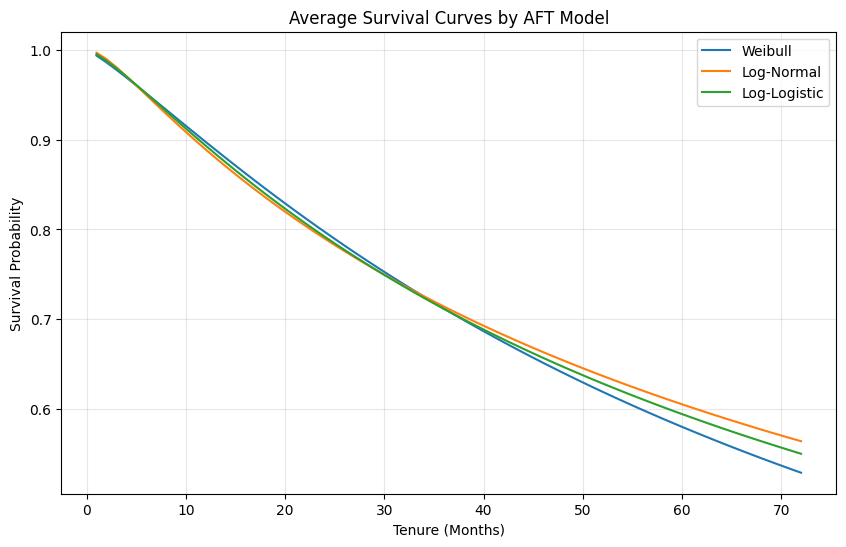

In [5]:
# Visualization: One plot for all curves
plt.figure(figsize=(10, 6))
weibull_aft.predict_survival_function(df_encoded).mean(axis=1).plot(label='Weibull')
lognorm_aft.predict_survival_function(df_encoded).mean(axis=1).plot(label='Log-Normal')
loglogis_aft.predict_survival_function(df_encoded).mean(axis=1).plot(label='Log-Logistic')
plt.title('Average Survival Curves by AFT Model')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# KEEP SIGNIFICANT FEATURES AND FINAL MODEL

In [7]:
# Extract p-values from the best model
p_values = best_model.summary['p']

# Get the list of significant variables (p < 0.05)
significant_vars = p_values[p_values < 0.05].index.get_level_values(1).unique().tolist()

# Exclude any variation of the intercept term ('_intercept' or 'Intercept')
significant_vars = [var for var in significant_vars if var not in ['_intercept', 'Intercept']]

# Ensure tenure and churn are included for the refit
cols_to_keep = list(set(significant_vars + ['tenure', 'churn']))
df_final = df_encoded[cols_to_keep]

# Refit the final model
final_model = models[best_model_name].__class__() # Creates a new instance of the best model type
final_model.fit(df_final, duration_col='tenure', event_col='churn')

print("\nFinal Model Summary (Significant Features Only):")
final_model.print_summary()


Final Model Summary (Significant Features Only):


<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.10
         time fit was run = 2026-05-09 09:41:34 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      1.03      2.79      0.17            0.69            1.36                2.00                3.89
       custcat_Plus service   0.82      2.28      0.17            0.49            1.15                1.63                3.17
       custcat_Total service  1.01      2.75      0.21            0.60            1.42                1.83                4.15
       internet_Yes          -0.84      0.43      0.14           -1.11           -0.57                0.33                0.57
       marital_Unmarried     -0.45      0.64      0.11           -0.67           -0.22                0.51                0.80
       voice_Yes             -0.46      0.63      0.17           -0.79           -0.14                0.45                0.87
       Intercept              2.53     12.62      0.24            2.06            3.01                7.84               20.30
sigma_ Intercept              0.28      1.33      0.05            0.19            0.37                1.21                1.45

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  4.84 <0.005     19.56
       age                      0.00  5.75 <0.005     26.78
       custcat_E-service        0.00  6.07 <0.005     29.53
       custcat_Plus service     0.00  4.85 <0.005     19.66
       custcat_Total service    0.00  4.83 <0.005     19.52
       internet_Yes             0.00 -6.08 <0.005     29.63
       marital_Unmarried        0.00 -3.91 <0.005     13.39
       voice_Yes                0.00 -2.78   0.01      7.52
       Intercept                0.00 10.45 <0.005     82.47
sigma_ Intercept                0.00  6.15 <0.005     30.27
---
Concordance = 0.78
AIC = 2944.20
log-likelihood ratio test = 280.83 on 8 df
-log2(p) of ll-ratio test = 183.73

# CLV CALCULATION

In [8]:
# Assumptions for standard Telco CLV logic:
# Monthly Margin = Average Monthly Revenue - Costs (Assuming a placeholder of $10 per month)
# Monthly Discount Rate = 10% annual / 12
margin = 10
r = 0.10 / 12
sequence_of_months = range(1, 73) # Projecting for a 72-month lifecycle

# Predict survival function for all users using the final model
survival_probs = final_model.predict_survival_function(df_final, times=sequence_of_months)

# Calculate CLV: Sum of (Survival_Prob * Margin) / (1 + r)^t
clv_scores = []
for idx in df_final.index:
    clv = sum((survival_probs.loc[t, idx] * margin) / ((1 + r)**t) for t in sequence_of_months)
    clv_scores.append(clv)

df_encoded['CLV'] = clv_scores
df['CLV'] = clv_scores # Append to original unencoded df for easier segmentation analysis

# Explore CLV within different segments (Example: by Customer Category and Internet)
print("\nAverage CLV by Customer Category:")
print(df.groupby('custcat')['CLV'].mean().sort_values(ascending=False))

print("\nAverage CLV by Internet Service:")
print(df.groupby('internet')['CLV'].mean().sort_values(ascending=False))


Average CLV by Customer Category:
custcat
Plus service     463.734229
E-service        441.905938
Total service    383.903174
Basic service    345.942846
Name: CLV, dtype: float64

Average CLV by Internet Service:
internet
No     442.947986
Yes    350.222081
Name: CLV, dtype: float64


# RETENTION BUDGET CALCULATION

In [9]:
# Identify "at-risk" subscribers
# Rule: Currently alive (churn==0), and conditional probability of churning within the next 12 months > 50%
alive_df = df_final[df_final['churn'] == 0].copy()

at_risk_count = 0
total_at_risk_clv = 0

for idx, row in alive_df.iterrows():
    current_tenure = row['tenure']
    target_tenure = current_tenure + 12

    # Probability of surviving to target_tenure GIVEN they survived to current_tenure
    # P(T > t+12 | T > t) = S(t+12) / S(t)
    prob_surv_current = final_model.predict_survival_function(alive_df.loc[[idx]], times=[current_tenure]).iloc[0, 0]
    prob_surv_target = final_model.predict_survival_function(alive_df.loc[[idx]], times=[target_tenure]).iloc[0, 0]

    conditional_survival = prob_surv_target / prob_surv_current
    churn_risk_next_year = 1 - conditional_survival

    # If chance of churning in next year is > 50%, flag as at risk
    if churn_risk_next_year > 0.50:
        at_risk_count += 1
        total_at_risk_clv += df_encoded.loc[idx, 'CLV']

# Budget formulation: We are willing to spend up to 10% of an at-risk customer's expected CLV to retain them.
retention_budget = total_at_risk_clv * 0.10

print(f"\nNumber of at-risk subscribers within a year: {at_risk_count}")
print(f"Total CLV of at-risk subscribers: ${total_at_risk_clv:.2f}")
print(f"Suggested Annual Retention Budget (Assuming 10% CLV allocation): ${retention_budget:.2f}")


Number of at-risk subscribers within a year: 2
Total CLV of at-risk subscribers: $248.54
Suggested Annual Retention Budget (Assuming 10% CLV allocation): $24.85
